In [1]:
#Loading libraries
library(dplyr)
library(tidyr)
library(UpSetR)
library(ggplot2)
library(purrr)
library(igraph)
library(ggraph)
library(Cairo)
library(patchwork)
library(readr)
library(stringr)

Warning message:
“package ‘dplyr’ was built under R version 4.5.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘tidyr’ was built under R version 4.5.2”
Warning message:
“package ‘UpSetR’ was built under R version 4.5.2”
Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”
Warning message:
“package ‘purrr’ was built under R version 4.5.2”
Warning message:
“package ‘igraph’ was built under R version 4.5.2”

Attaching package: ‘igraph’


The following objects are masked from ‘package:purrr’:

    compose, simplify


The following object is masked from ‘package:tidyr’:

    crossing


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘pac

In [2]:
#Loading table with cluster assignments
master <- read.delim(
    "arch_cluster_master.tsv",
    header = FALSE,
    stringsAsFactors = FALSE)

colnames(master) <- c("Cluster",
    "Protein","Genome",
    "Contig","Replicon")

#Loading taxonomy table
taxonomy <- read.delim("genome_taxonomy.tsv",
    stringsAsFactors = FALSE)

#Loading complete replicon metadata
replicon_all_metadata_tax <- read.delim("replicon_all_metadata_tax.tsv",
    stringsAsFactors = FALSE)

#Keep only Halobacteriota
master <- master %>%
    inner_join(taxonomy %>%
            select(genome, phylum),
        by = c("Genome" = "genome")) %>%
    filter(phylum == "Halobacteriota")

#Keep only Halobacteriota replicons from the complete metadata
replicon_counts <- replicon_all_metadata_tax %>%
    filter(phylum == "Halobacteriota") %>%
    distinct(genome,
        contig,
        replicon) %>%
    count(replicon,
        name = "N_replicons")

#Verifying replicon type counts
replicon_counts

n_chr1 <- replicon_counts$N_replicons[replicon_counts$replicon=="chr1"]
n_chr2 <- replicon_counts$N_replicons[replicon_counts$replicon=="chr2plus"]
n_plas <- replicon_counts$N_replicons[replicon_counts$replicon=="plasmid"]

replicon,N_replicons
<chr>,<int>
chr1,211
chr2plus,9
plasmid,546


In [3]:
#Building cluster x replicon matrix
cluster_matrix <- master %>%
    distinct(Cluster, Contig, Replicon) %>%
    count(Cluster, Replicon, name="N") %>%
    pivot_wider(
        names_from = Replicon,
        values_from = N,
        values_fill = 0)

head(cluster_matrix)

#Calculating lists and percentages
n_chr1 <- replicon_counts$N_replicons[replicon_counts$replicon=="chr1"]
n_chr2 <- replicon_counts$N_replicons[replicon_counts$replicon=="chr2plus"]
n_plas <- replicon_counts$N_replicons[replicon_counts$replicon=="plasmid"]

cluster_matrix_pct <- cluster_matrix %>%
    mutate(
        chr1_pct = ifelse(chr1 > 0, 100*chr1/n_chr1, 0),
        chr2plus_pct = ifelse(chr2plus > 0, 100*chr2plus/n_chr2, 0),
        plasmid_pct = ifelse(plasmid > 0, 100*plasmid/n_plas, 0))

head(cluster_matrix_pct)

Cluster,chr1,plasmid,chr2plus
<chr>,<int>,<int>,<int>
AAFHMIJB_00153,9,0,0
AAFHMIJB_00175,8,0,0
AAFHMIJB_00208,15,0,0
AAFHMIJB_00210,2,0,0
AAFHMIJB_00224,9,0,0
AAFHMIJB_00225,3,0,0


Cluster,chr1,plasmid,chr2plus,chr1_pct,chr2plus_pct,plasmid_pct
<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
AAFHMIJB_00153,9,0,0,4.2654028,0,0
AAFHMIJB_00175,8,0,0,3.7914692,0,0
AAFHMIJB_00208,15,0,0,7.1090047,0,0
AAFHMIJB_00210,2,0,0,0.9478673,0,0
AAFHMIJB_00224,9,0,0,4.2654028,0,0
AAFHMIJB_00225,3,0,0,1.4218009,0,0


In [4]:
#USING REPLICONS AS COMPARISON UNITS
#Doing an UpSetR using genomes as replicon units would be too huge

'data.frame':	123051 obs. of  3 variables:
 $ chr1    : num  1 1 1 1 1 1 1 1 1 1 ...
 $ chr2plus: num  0 0 0 0 0 0 0 0 0 0 ...
 $ plasmid : num  0 0 0 0 0 0 0 0 0 0 ...


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue at <https://github.com/hms-dbmi/UpSetR/issues>.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue at <https://github.com/hms-dbmi/UpSetR/issues>.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue at <https://github.com/hms-dbmi/UpSetR/issues>.”


agg_record_130e37eb95c5 
                      2

Cluster,chr1,plasmid,chr2plus,chr1_pct,chr2plus_pct,plasmid_pct,Group
<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
AAFHMIJB_00153,9,0,0,4.2654028,0,0,chr1 unique
AAFHMIJB_00175,8,0,0,3.7914692,0,0,chr1 unique
AAFHMIJB_00208,15,0,0,7.1090047,0,0,chr1 unique
AAFHMIJB_00210,2,0,0,0.9478673,0,0,chr1 unique
AAFHMIJB_00224,9,0,0,4.2654028,0,0,chr1 unique
AAFHMIJB_00225,3,0,0,1.4218009,0,0,chr1 unique


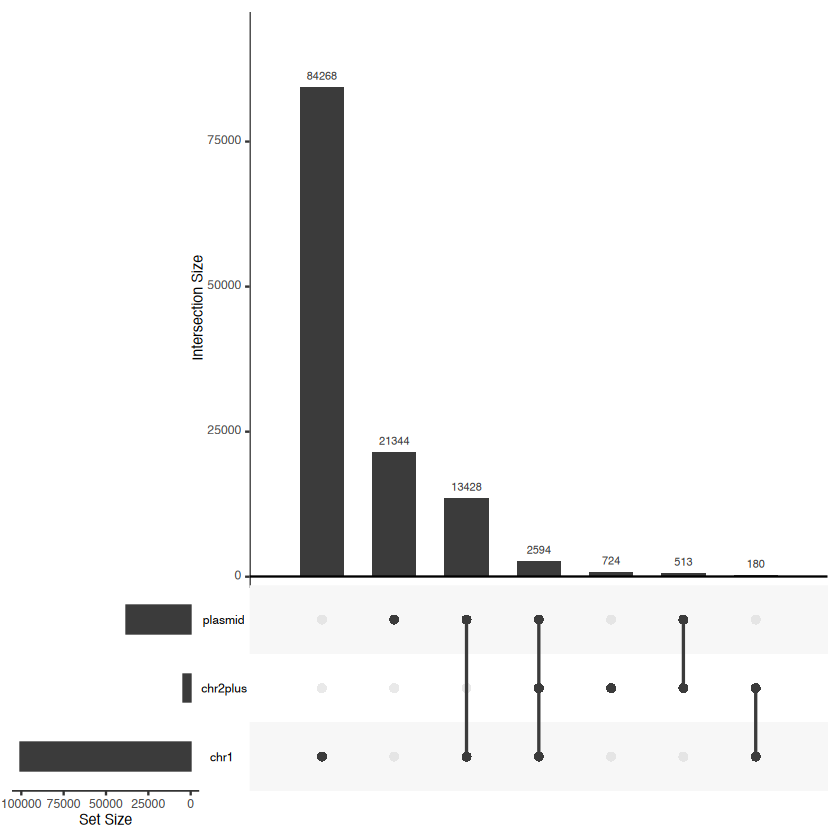

In [5]:
#UpSetR plot
cluster_matrix_pct <- cluster_matrix_pct 

upset_data <- data.frame(chr1 = as.numeric(cluster_matrix_pct$chr1 > 0),
    chr2plus  = as.numeric(cluster_matrix_pct$chr2plus > 0),
    plasmid   = as.numeric(cluster_matrix_pct$plasmid > 0),
    check.names = FALSE)

str(upset_data)

upset(upset_data,
    sets = c("chr1","chr2plus","plasmid"),
    keep.order = TRUE,
    order.by = "freq")

pdf("./paper/upset.pdf",
  width = 8,
  height = 6)

upset(upset_data,
    sets = c("chr1","chr2plus","plasmid"),
    keep.order = TRUE,
    order.by = "freq")
dev.off()

#Getting the list for each category from the UpSetR
cluster_groups <- cluster_matrix_pct %>%
  mutate(Group = case_when(
      chr1 > 0 & chr2plus == 0 & plasmid == 0 ~ "chr1 unique",
      chr1 == 0 & chr2plus > 0 & plasmid == 0 ~ "chr2plus unique",
      chr1 == 0 & chr2plus == 0 & plasmid > 0 ~ "plasmid unique",
      chr1 > 0 & chr2plus > 0 & plasmid == 0 ~ "shared chr1 + chr2plus",
      chr1 > 0 & chr2plus == 0 & plasmid > 0 ~ "shared chr1 + plasmid",
      chr1 == 0 & chr2plus > 0 & plasmid > 0 ~ "shared chr2plus + plasmid",
      chr1 > 0 & chr2plus > 0 & plasmid > 0 ~ "core",
      TRUE ~ "absent"))
head(cluster_groups)

In [6]:
#Loading annotation table
anno <- read.delim("arch_cluster_annotation.tsv",stringsAsFactors = FALSE)
cluster_annotation <- cluster_matrix_pct %>%
    left_join(anno, by = c("Cluster" = "cluster"))

#Merging with the annotation table
cluster_summary <- cluster_groups %>%
  left_join(cluster_annotation, by = "Cluster") %>%
  select(Cluster,
    COG_category,
    Description,Group)
head(cluster_summary)
write.table(cluster_summary, "./paper/upset.tsv", sep="\t", quote=FALSE, row.names=FALSE)

Cluster,COG_category,Description,Group
<chr>,<chr>,<chr>,<chr>
AAFHMIJB_00153,-,-,chr1 unique
AAFHMIJB_00175,T,COG0642 Signal transduction histidine kinase,chr1 unique
AAFHMIJB_00208,-,-,chr1 unique
AAFHMIJB_00210,D,cell wall organization,chr1 unique
AAFHMIJB_00224,-,-,chr1 unique
AAFHMIJB_00225,-,-,chr1 unique


In [7]:
#Calculating a pangenome per each replicon type

In [8]:
#Loading tables
master <- read.delim("arch_cluster_master.tsv",header = FALSE,stringsAsFactors = FALSE)
colnames(master) <- c("Cluster",
  "Protein",
  "Genome",
  "Contig",
  "Replicon")
meta <- read.delim("replicon_all_metadata_tax_2.tsv",stringsAsFactors = FALSE)

# Keep only Halobacteriota genomes
master <- master %>%
  filter(Genome %in% meta$genome[meta$phylum == "Halobacteriota"]) %>%
  filter(Replicon %in% c("chr1", "chr2plus", "plasmid"))

# Analyze each replicon type separately
replicon_types <- c("chr1", "chr2plus", "plasmid")
results <- list()
for(rep_type in replicon_types){
  cat("\n=============================\n")
  cat(rep_type, "\n")
  tmp <- master %>%
    filter(Replicon == rep_type)
  #Number of replicons of this type
  n_rep <- tmp %>%
    distinct(Contig) %>%
    nrow()
  cat("Replicons:", n_rep, "\n")
  # Frequency of each cluster
  cluster_freq <- tmp %>%
    distinct(Cluster, Contig) %>%
    count(Cluster, name = "Replicons") %>%
    mutate(
      Frequency = 100 * Replicons / n_rep,
      Category = case_when(
        Replicons == 1 ~ "Singleton",
        Frequency >= 95 ~ "Core",
        Frequency >= 80 ~ "Soft-core",
        Frequency >= 15 ~ "Accessory",
        TRUE ~ "Rare"))

  #Summary
  summary_table <- cluster_freq %>%
    count(Category) %>%
    mutate(Replicon = rep_type)

  print(summary_table)
  results[[rep_type]] <- list(
    cluster_frequency = cluster_freq,
    summary = summary_table)}

#Combined summary
summary_all <- bind_rows(lapply(results, function(x) x$summary))

summary_all$Category <- factor(summary_all$Category,
  levels = c("Core",
    "Soft-core",
    "Accessory",
    "Rare",
    "Singleton"))

summary_all <- summary_all %>%
  arrange(Replicon, Category)


chr1 
Replicons: 211 
   Category     n Replicon
1 Accessory  2879     chr1
2      Core   115     chr1
3      Rare 41325     chr1
4 Singleton 56263     chr1
5 Soft-core   732     chr1

chr2plus 
Replicons: 9 
   Category    n Replicon
1 Accessory  730 chr2plus
2 Singleton 3280 chr2plus
3 Soft-core    1 chr2plus

plasmid 
Replicons: 543 
   Category     n Replicon
1 Accessory    35  plasmid
2      Rare 14587  plasmid
3 Singleton 23591  plasmid


Saving 6.67 x 6.67 in image


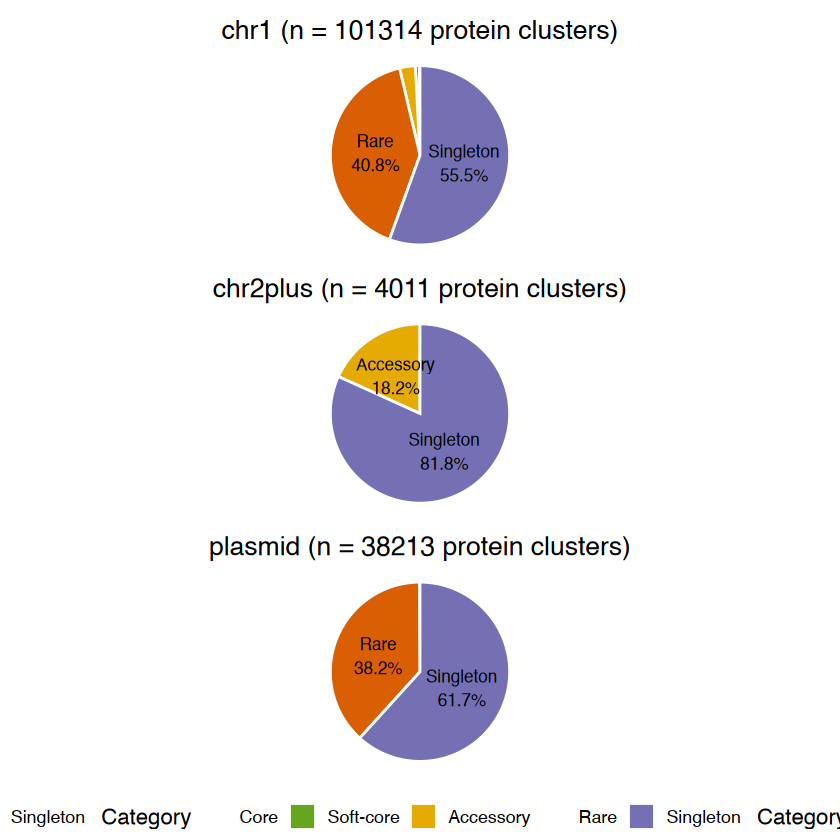

In [9]:
#Plotting the different pangenome categories
#Order of categories
summary_all$Category <- factor(
  summary_all$Category,
  levels = c(
    "Core",
    "Soft-core",
    "Accessory",
    "Rare",
    "Singleton"))

#Color palette
cols <- c("Core" = "#1b9e77",
  "Soft-core" = "#66a61e",
  "Accessory" = "#e6ab02",
  "Rare" = "#d95f02",
  "Singleton" = "#7570b3")

#Function to create one pie chart
make_pie <- function(rep_type){
  dat <- summary_all %>%
    filter(Replicon == rep_type) %>%
    mutate(
      Percent = 100 * n / sum(n),
      Label = paste0(Category, "\n", round(Percent,1), "%"))
  ggplot(dat,aes(x = "", y = n, fill = Category)) +
    geom_col(width = 1, colour = "white") +
    coord_polar(theta = "y") +
    scale_fill_manual(values = cols, drop = FALSE) +
    geom_text(
      aes(label = ifelse(Percent >= 3, Label, "")),
      position = position_stack(vjust = 0.5),
      size = 3.5) +
    labs(title = paste0(rep_type, " (n = ", sum(dat$n), " protein clusters)")) +
    theme_void(base_size = 13) +
    theme(plot.title = element_text(hjust = 0.5, face = "bold"),
      legend.position = "right")}

# Create the three plots
p_chr1 <- make_pie("chr1")
p_chr2 <- make_pie("chr2plus")
p_plas <- make_pie("plasmid")

#Combine
(p_chr1 / p_chr2 / p_plas) +
  plot_layout(guides = "collect") &
  theme(legend.position = "bottom")
ggsave("./paper/pie_chart_pangenome.svg")

In [10]:
#Creating annotations tables for each pangenome
#Read cluster assignments
master <- read.delim("arch_cluster_master.tsv",header = FALSE,stringsAsFactors = FALSE)
colnames(master) <- c("cluster",
  "protein",
  "genome",
  "contig",
  "replicon")

#Read taxonomy
tax <- read.delim("replicon_all_metadata_tax_2.tsv",stringsAsFactors = FALSE) %>%
  select(genome, phylum, family) %>%
  distinct()

#Merge taxonomy
master <- master %>%
  left_join(tax, by = "genome") %>%
  filter(phylum == "Halobacteriota",
    replicon %in% c("chr1","chr2plus","plasmid"))
colnames(cluster_summary)

#Read cluster annotations
annot <- cluster_summary %>%
  select(cluster = Cluster,
    Description,
    COG_category) %>%
  distinct()

[1] "Cluster"      "COG_category" "Description"  "Group"

In [11]:
#Create one table per replicon
replicons <- c("chr1","chr2plus","plasmid")
for(rep_type in replicons){cat("\nProcessing",rep_type,"\n")
  tmp <- master %>%
    filter(replicon == rep_type)
  n_rep <- n_distinct(tmp$contig)
  cluster_table <- tmp %>%
    distinct(cluster,
             contig,
             family,
             phylum) %>%
    count(cluster,
          name = "Replicons") %>%
    mutate(
      Frequency = 100 * Replicons / n_rep,
      Category = case_when(
        Replicons == 1 ~ "Singleton",
        Frequency >= 95 ~ "Core",
        Frequency >= 80 ~ "Soft-core",
        Frequency >= 15 ~ "Accessory",
        TRUE ~ "Rare"))
  taxonomy <- tmp %>%
    group_by(cluster) %>%
    summarise(
      Phylum = first(phylum),
      Families = paste(sort(unique(family)),
                       collapse = "; "),.groups = "drop")
  final_table <- cluster_table %>%
    left_join(annot, by = "cluster") %>%
    left_join(taxonomy, by = "cluster") %>%
    arrange(factor(Category,
             levels = c("Core",
               "Soft-core",
               "Accessory",
               "Rare",
               "Singleton")),
      desc(Frequency))
   #Create output directory if it doesn't exist
    dir.create("./figures", showWarnings = FALSE)
   #Save table
   write.table(final_table,
     file = file.path("./paper",paste0(rep_type, "_cluster_list.tsv")),
     sep = "\t",
     quote = FALSE,
     row.names = FALSE)}


Processing chr1 

Processing chr2plus 

Processing plasmid 


In [12]:
#Calculating pangenome using GENOME as the observational cluster instead of replicon

In [13]:
#Read genome-level cluster counts
clust <- read.delim(
    "arch_cluster_genome_replicon_counts.tsv",
    header = FALSE,
    stringsAsFactors = FALSE,
    col.names = c("cluster", "genome", "replicon", "copies")
)
tax <- read.delim( "replicon_metadata_tax.tsv",stringsAsFactors = FALSE) %>%
  select(genome, family) %>%
  distinct()

#Keep families with >=10 genomes
good_families <- tax %>%
  count(family, name="Ngenomes") %>%
  filter(Ngenomes >= 10)

tax <- tax %>%
  filter(family %in% good_families$family)

#Merge taxonomy
clust <- left_join(clust,tax,by="genome") %>%
  filter(!is.na(family),
         replicon %in% c("chr1","chr2plus","plasmid"))

#Collapse to PRESENCE/ABSENCE PER GENOME
presence <- clust %>%
  group_by(family,
    replicon,
    genome,
    cluster) %>%
  summarise(.groups="drop")

#Genome-level pangenomes
pan_summary <- presence %>%
  group_by(family, replicon) %>%
  group_modify(~{
    dat <- .
    ngenomes <- n_distinct(dat$genome)
    freq <- dat %>%
      count(cluster,name="Genomes") %>%
      mutate(Frequency = 100*Genomes/ngenomes,
        Category = case_when(
          Genomes == 1 ~ "Singleton",
          Frequency >= 95 ~ "Core",
          Frequency >= 80 ~ "Soft-core",
          Frequency >= 15 ~ "Accessory",
          TRUE ~ "Rare"))
    tibble(Ngenomes = ngenomes,
      TotalClusters = nrow(freq),
      Core = sum(freq$Category=="Core"),
      SoftCore = sum(freq$Category=="Soft-core"),
      Accessory = sum(freq$Category=="Accessory"),
      Rare = sum(freq$Category=="Rare"),
      Singleton = sum(freq$Category=="Singleton"))}) %>%
  ungroup() %>%
  mutate(CoreFraction = Core/TotalClusters,
    SoftCoreFraction = SoftCore/TotalClusters,
    AccessoryFraction = Accessory/TotalClusters,
    RareFraction = Rare/TotalClusters,
    SingletonFraction = Singleton/TotalClusters)
head(pan_summary)
write.table(pan_summary,"./paper/family_genome_pangenome.tsv",sep="\t",quote=FALSE,row.names=FALSE)

family,replicon,Ngenomes,TotalClusters,Core,SoftCore,Accessory,Rare,Singleton,CoreFraction,SoftCoreFraction,AccessoryFraction,RareFraction,SingletonFraction
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Haladaptataceae,chr1,14,11986,18,1263,2902,1527,6276,0.0015017520,0.105372935,0.24211580,0.1273986,0.5236109
Haladaptataceae,chr2plus,1,1378,0,0,0,0,1378,0.0000000000,0.000000000,0.00000000,0.0000000,1.0000000
Haladaptataceae,plasmid,14,10933,9,44,1796,1512,7572,0.0008231958,0.004024513,0.16427330,0.1382969,0.6925821
Haloarculaceae,chr1,54,37166,723,319,3097,12705,20322,0.0194532637,0.008583114,0.08332885,0.3418447,0.5467901
Haloarculaceae,chr2plus,5,1559,0,10,369,0,1180,0.0000000000,0.006414368,0.23669019,0.0000000,0.7568954
Haloarculaceae,plasmid,54,12260,0,0,363,4434,7463,0.0000000000,0.000000000,0.02960848,0.3616639,0.6087276


In [14]:
#Determining genome count per family
tax %>%
  count(family, name = "Ngenomes") %>%
  filter(Ngenomes >= 10) %>%
  arrange(desc(Ngenomes))

family,Ngenomes
<chr>,<int>
Haloferacaceae,58
Haloarculaceae,54
Natrialbaceae,44
Halobacteriaceae,20
Haladaptataceae,14


In [15]:
#Building the pangenome for each of the five families
#Reading table files
metadata <- read.delim(
  "replicon_all_metadata_tax.tsv",
  stringsAsFactors = FALSE)

markers <- read.delim(
  "replicon_features_markers.tsv",
  stringsAsFactors = FALSE)

markers <- markers %>%
  select(genome,
    contig,
    starts_with("CHR_"),
    starts_with("PART_"),
    starts_with("PLAS_"),
    codon_corr_chr1)

replicon_all <- metadata %>%
  left_join(markers, by = c("genome", "contig"))

feat <- replicon_all %>%
  filter(
    phylum == "Halobacteriota",
    !is.na(codon_corr_chr1)) %>%
  mutate(
    logLength = log10(length))

#Creating master dataset
master <- master %>%
  rename_with(tolower)
head(master)
genes <- master %>%
  left_join(
    feat %>%
      select(genome, contig, length, genus, species) %>%
      distinct(),
    by = c("genome", "contig")
  ) %>%
  filter(
    phylum == "Halobacteriota",
    family %in% good_families$family,
    replicon %in% c("chr1", "chr2plus", "plasmid")
  )

#Family-specific pangenome
pan_lookup <- genes %>%
  group_by(family) %>%
  group_modify(~{
    tmp <- .x %>%
      distinct(genome, cluster)
    ngenomes <- n_distinct(tmp$genome)
    tmp %>%
      count(cluster, name = "Ngenomes") %>%
      mutate(Frequency = 100 * Ngenomes / ngenomes,
        PangenomeClass = case_when(
          Ngenomes == 1 ~ "Singleton",
          Frequency >= 95 ~ "Core",
          Frequency >= 80 ~ "Soft-core",
          Frequency >= 15 ~ "Accessory",
          TRUE ~ "Rare") )}) %>%
  ungroup()

#Adding pangenome class to every gene
genes <- genes %>%
  left_join(pan_lookup,by = c("family","cluster"))

#Adding functional annotation
genes <- genes %>%
  left_join(annot,by = "cluster")

#Final check
summary(genes$PangenomeClass)
table(genes$family)
head(genes)

,cluster,protein,genome,contig,replicon,phylum,family
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,BKFBJDIK_00146,BKFBJDIK_00146,GCF_000969945.1,NZ_CP009524.1,chr1,Halobacteriota,Methanosarcinaceae
2,BKFBJDIK_00146,OAPEMJJH_03971,GCF_000969985.1,NZ_CP009526.1,chr1,Halobacteriota,Methanosarcinaceae
3,BKFBJDIK_00146,NFPFFJMG_03584,GCF_000970065.1,NZ_CP009530.1,chr1,Halobacteriota,Methanosarcinaceae
4,BKFBJDIK_00146,FPPDMBCC_00145,GCF_000969905.1,NZ_CP009520.1,chr1,Halobacteriota,Methanosarcinaceae
5,BKFBJDIK_00146,FMDHGICI_03667,GCF_000970025.1,NZ_CP009528.1,chr1,Halobacteriota,Methanosarcinaceae
6,BKFBJDIK_00146,CEIJLHDF_00922,GCF_000328665.1,NC_019977.1,chr1,Halobacteriota,Methanosarcinaceae


   Length     Class      Mode 
   746693 character character 


 Haladaptataceae   Haloarculaceae Halobacteriaceae   Haloferacaceae 
           68030           218747            54338           211930 
   Natrialbaceae 
          193648 

,cluster,protein,genome,contig,replicon,phylum,family,length,genus,species,Ngenomes,Frequency,PangenomeClass,Description,COG_category
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>
1,JDDMCGKP_03353,JDDMCGKP_03353,GCF_020405225.1,NZ_CP084472.1,chr1,Halobacteriota,Natrialbaceae,4109150,Natrinema,Natrinema sp020405225,23,52.27273,Accessory,"COG1175 ABC-type sugar transport systems, permease components",P
2,JDDMCGKP_03353,MHLCOKCG_02318,GCF_024227435.1,NZ_CP100445.1,chr1,Halobacteriota,Natrialbaceae,3942503,Natrinema,Natrinema sp024227435,23,52.27273,Accessory,"COG1175 ABC-type sugar transport systems, permease components",P
3,JDDMCGKP_03353,OFLFEDBD_01407,GCF_017352155.2,NZ_CP071462.1,chr1,Halobacteriota,Natrialbaceae,3823492,Haloterrigena,Haloterrigena alkaliphila,23,52.27273,Accessory,"COG1175 ABC-type sugar transport systems, permease components",P
4,JDDMCGKP_03353,MCPNLMJI_02876,GCF_013402815.2,NZ_CP058601.1,chr1,Halobacteriota,Natrialbaceae,4359796,Natrinema,Natrinema halophilum,23,52.27273,Accessory,"COG1175 ABC-type sugar transport systems, permease components",P
5,JDDMCGKP_03353,PJGOAODJ_01484,GCF_024218815.1,NZ_CP100407.1,chr1,Halobacteriota,Haloarculaceae,3318558,Halomicroarcula,Halomicroarcula sp024218775,32,59.25926,Accessory,"COG1175 ABC-type sugar transport systems, permease components",P
6,JDDMCGKP_03353,NAAAAIDP_01066,GCF_049603855.1,NZ_CP187146.1,chr1,Halobacteriota,Haloarculaceae,3375170,Haloarcula,,32,59.25926,Accessory,"COG1175 ABC-type sugar transport systems, permease components",P


family,PangenomeClass,replicon,n,Fraction
<chr>,<fct>,<chr>,<int>,<dbl>
Haladaptataceae,Accessory,chr1,3743,0.49510582
Haladaptataceae,Accessory,chr2plus,578,0.07645503
Haladaptataceae,Accessory,plasmid,3239,0.42843915
Haladaptataceae,Core,chr1,1184,0.47473937
Haladaptataceae,Core,chr2plus,126,0.05052125
Haladaptataceae,Core,plasmid,1184,0.47473937


Saving 6.67 x 6.67 in image


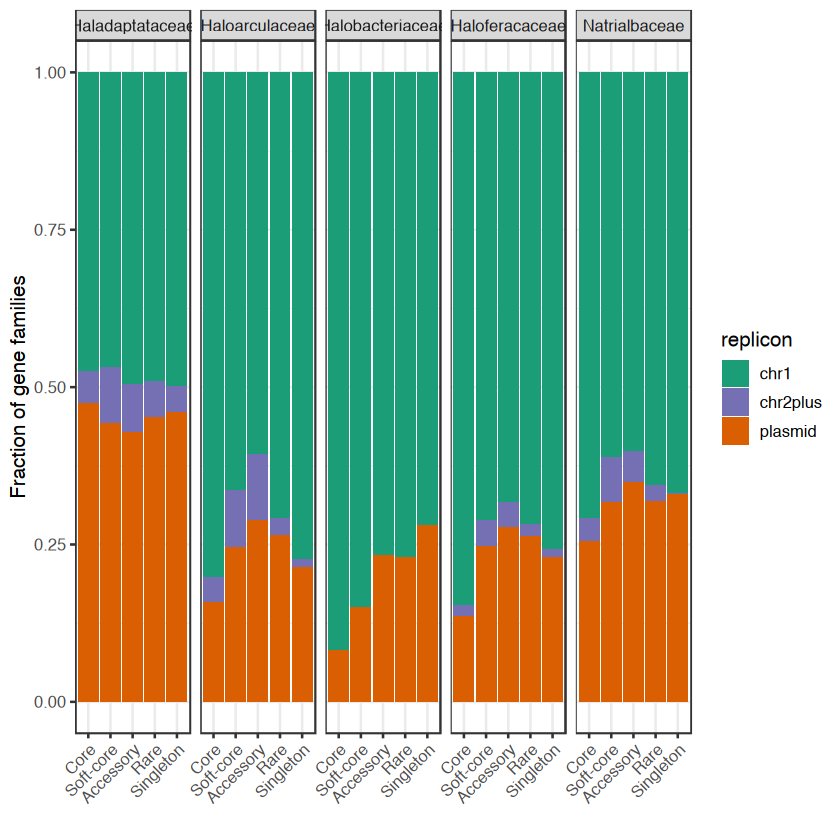

In [16]:
#Where are pangenome classes located?
replicon_location <- genes %>%
  distinct(family,
    replicon,
    cluster,
    PangenomeClass) %>%
  count(family,
    PangenomeClass,
    replicon) %>%
  group_by(family,
    PangenomeClass) %>%
  mutate(Fraction = n/sum(n)) %>%
  ungroup() %>%
    mutate(PangenomeClass = factor(PangenomeClass,
                                    levels = c("Core",
                                                "Soft-core",
                                               "Accessory",
                                               "Rare",
                                               "Singleton")))

head(replicon_location)

#Plotting
ggplot(replicon_location,
  aes(PangenomeClass,
    Fraction,
    fill=replicon))+
geom_col()+
facet_wrap(~family,nrow=1)+
scale_fill_manual(values=c(chr1="#1b9e77",
    chr2plus="#7570b3",
    plasmid="#d95f02"))+
theme_bw(base_size=12)+
theme(axis.text.x=element_text(
    angle=45,
    hjust=1))+
labs(x="",
  y="Fraction of gene families")
ggsave("./paper/pang_cat_per_replicon.svg")

In [17]:
#Creating supplementary tables
dir.create("./paper/family_annotation_tables", showWarnings = FALSE)

families <- sort(unique(genes$family))
for(fam in families){tab <- genes %>%
    filter(family == fam) %>%
    distinct(cluster, .keep_all = TRUE) %>%
    arrange(factor(PangenomeClass,
        levels = c("Core",
          "Soft-core",
          "Accessory",
          "Rare",
          "Singleton")),desc(Frequency)) %>%
    select(cluster,
      COG_category,
      PangenomeClass,
      Ngenomes,
      Frequency)

  write.csv(tab,file = file.path("./paper/family_annotation_tables",
      paste0(gsub(" ", "_", fam), "_annotation.csv")),
    row.names = FALSE)}

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 60 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 60 rows containing missing values or values outside the scale range (`geom_point()`).”
Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 60 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 60 rows containing missing values or values outside the scale range (`geom_point()`).”


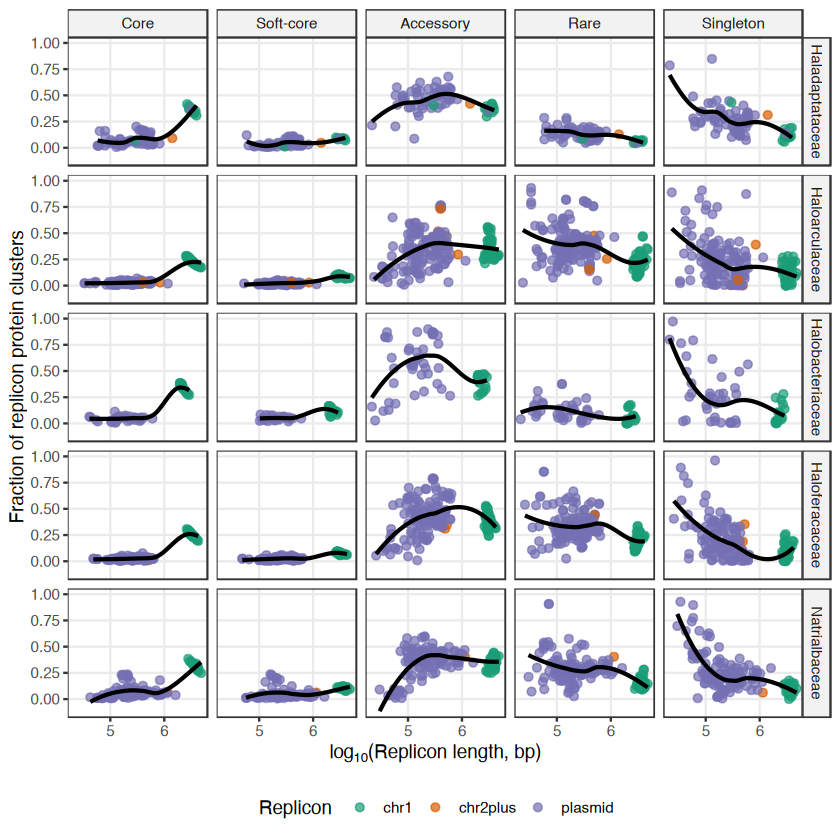

In [18]:
#Build replicon composition table
replicon_comp <- genes %>%
  distinct(family,
    genome,
    contig,
    replicon,
    length,
    cluster,
    PangenomeClass) %>%
  count(family,
    genome,
    contig,
    replicon,
    length,
    PangenomeClass,
    name = "N") %>%
  group_by(family,
    genome,
    contig) %>%
  mutate(Fraction = N / sum(N)) %>%
  ungroup()

# Keep facet order consistent
replicon_comp$PangenomeClass <- factor(
  replicon_comp$PangenomeClass,
  levels = c("Core",
    "Soft-core",
    "Accessory",
    "Rare",
    "Singleton"))

# Plotting faceted graphs
ggplot(replicon_comp,
  aes(x = log10(length),
    y = Fraction,
    colour = replicon)) +
  geom_point(alpha = 0.7,
    size = 1.8) +
  geom_smooth(aes(group = 1),
    method = "loess",
    se = FALSE,
    colour = "black",
    linewidth = 0.9) +
  facet_grid(family ~ PangenomeClass) +
  scale_colour_manual(values = c(chr1 = "#1b9e77",
      chr2plus = "#d95f02",
      plasmid = "#7570b3"),
    name = "Replicon") +
  labs(x = expression(log[10] * "(Replicon length, bp)"),
    y = "Fraction of replicon protein clusters") +
  theme_bw(base_size = 11) +
  theme(strip.background = element_rect(fill = "grey95"),
    panel.grid.minor = element_blank(),
    legend.position = "bottom",
    legend.title = element_text(face = "bold"))
ggsave("./paper/tendency_pang_cat.svg")

In [19]:
#Getting numbers for each pangenome category
pan_lookup <- genes %>%
  group_by(family) %>%
  group_modify(~{tmp <- .x %>%
      distinct(genome, cluster)
    ngenomes <- n_distinct(tmp$genome)
    tmp %>%
      count(cluster, name = "Ngenomes") %>%
      mutate(Frequency = 100 * Ngenomes / ngenomes,
        PangenomeClass = case_when(
          Ngenomes == 1 ~ "Singleton",
          Frequency >= 95 ~ "Core",
          Frequency >= 80 ~ "Soft-core",
          Frequency >= 15 ~ "Accessory",
          TRUE ~ "Rare") )}) %>%
  ungroup()

family_pan_summary <- pan_lookup %>%
  count(
    family,
    PangenomeClass,
    name = "Nclusters"
  ) %>%
  pivot_wider(
    names_from = PangenomeClass,
    values_from = Nclusters,
    values_fill = 0
  ) %>%
  mutate(
    Total = Core + `Soft-core` + Accessory + Rare + Singleton
  ) %>%
  arrange(family)

print(family_pan_summary, n = Inf)

# A tibble: 5 × 7
  family           Accessory  Core  Rare Singleton `Soft-core` Total
  <chr>                <int> <int> <int>     <int>       <int> <int>
1 Haladaptataceae       4619  1184  2482     10285         344 18914
2 Haloarculaceae        3779   740 15346     24378         330 44573
3 Halobacteriaceae      3311   780  1579      5110         344 11124
4 Haloferacaceae        4404   782 12039     17483         271 34979
5 Natrialbaceae         4019  1089 10000     19146         432 34686


In [20]:
#Checking shared proteins among replicons per genome with secondary replicons

In [21]:
#Build cluster sets
replicon_sets <- master %>%
  distinct(genome, contig, replicon, cluster) %>%
  group_by(genome, contig, replicon) %>%
  summarise(clusters = list(unique(cluster)),
    .groups = "drop")

#Compute pairwise sharing
edges <- replicon_sets %>%
  group_by(genome) %>%
  group_modify(~{genome_id <- .y$genome
    dat <- .x
    if(nrow(dat) < 2)
      return(tibble())
    comb <- t(combn(seq_len(nrow(dat)), 2))
    purrr::map_dfr(seq_len(nrow(comb)), function(i){
      a <- comb[i,1]
      b <- comb[i,2]
      A <- dat$clusters[[a]]
      B <- dat$clusters[[b]]
      shared <- length(intersect(A, B))
      if(shared == 0)
        return(tibble())
      tibble(
    from = dat$contig[a],
    to = dat$contig[b],
    shared = shared,
    jaccard = shared / length(union(A, B)),
    overlap = shared / min(length(A), length(B)))})}) %>%
  ungroup()

#Build node table
nodes <- replicon_sets %>%
  mutate(size = lengths(clusters),
    name = contig) %>%
  select(genome,
    name,
    replicon,
    size) %>%
  group_by(genome) %>%
  arrange(name, .by_group = TRUE) %>%
  mutate(plasmid_number = cumsum(replicon == "plasmid"),
    label = case_when(replicon == "chr1" ~ "chr1",
      replicon == "chr2plus" ~ "chr2",
      TRUE ~ paste0("p", plasmid_number))) %>%
  ungroup() %>%
  select(-plasmid_number)

#Genomes to plot
genomes <- c("GCF_020618475.1",
  "GCF_027563145.1",
  "GCF_017357405.2",
  "GCF_051122755.1",
  "GCF_020150815.1",
  "GCF_000022205.1",
  "GCF_000011085.1",
  "GCF_000223905.1",
  "GCF_000504565.1")

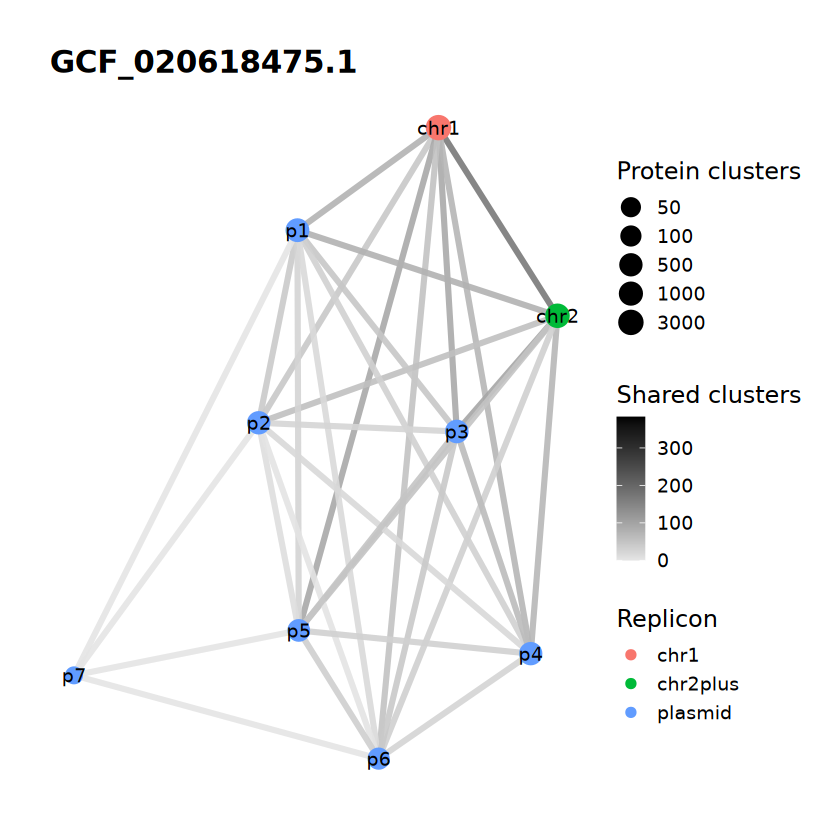

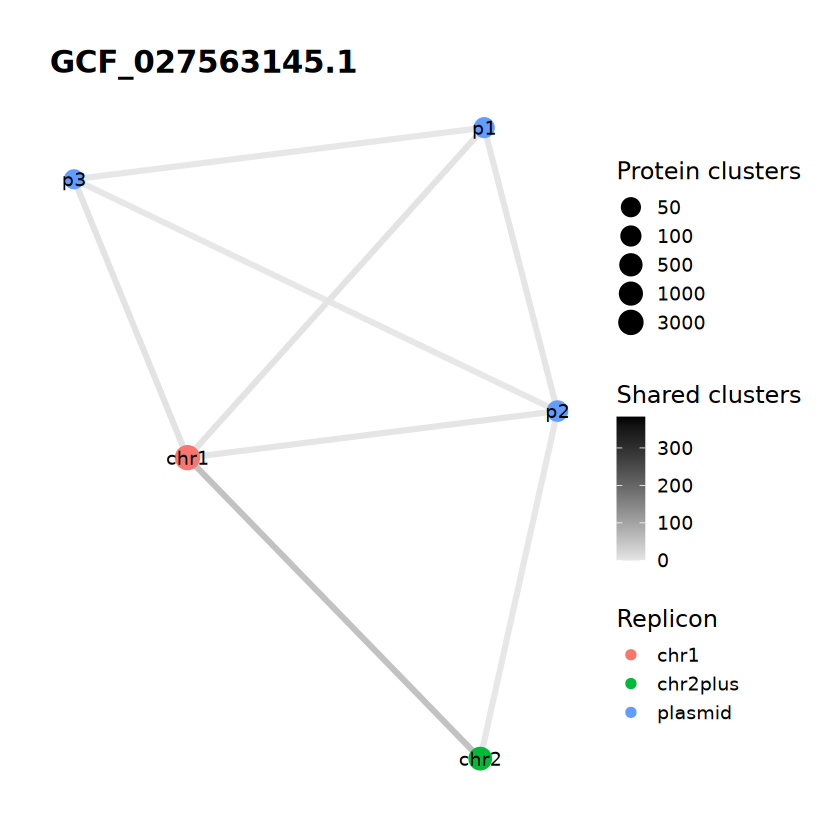

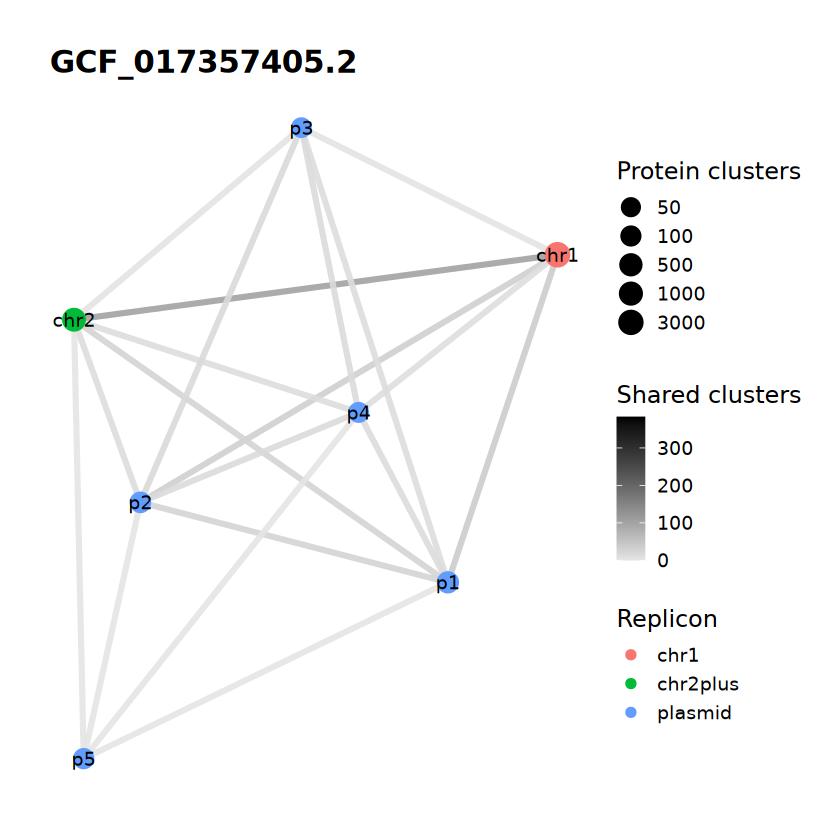

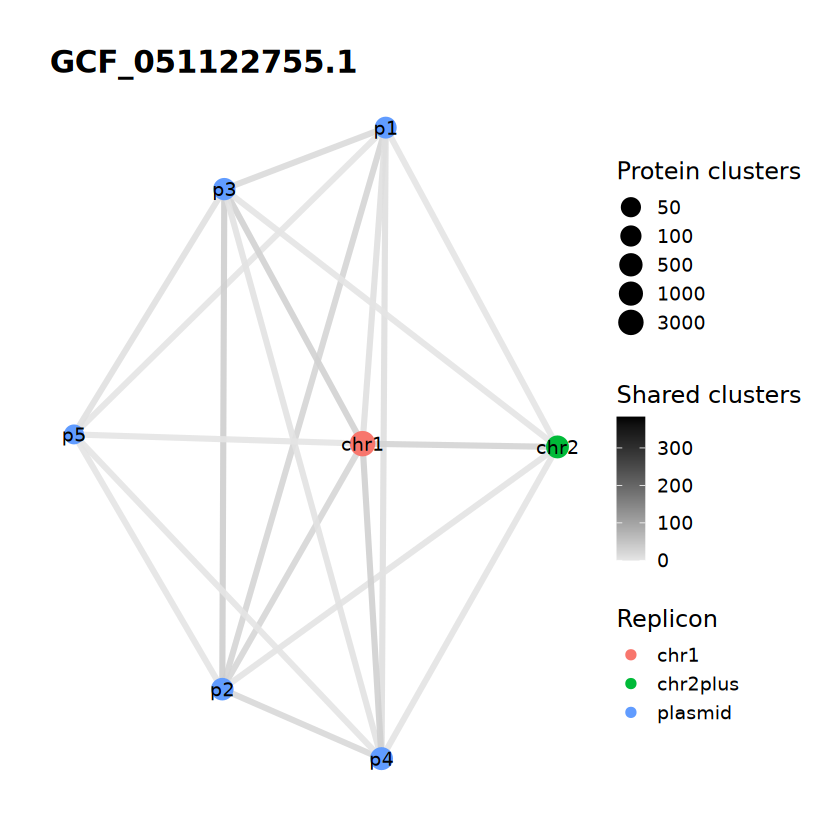

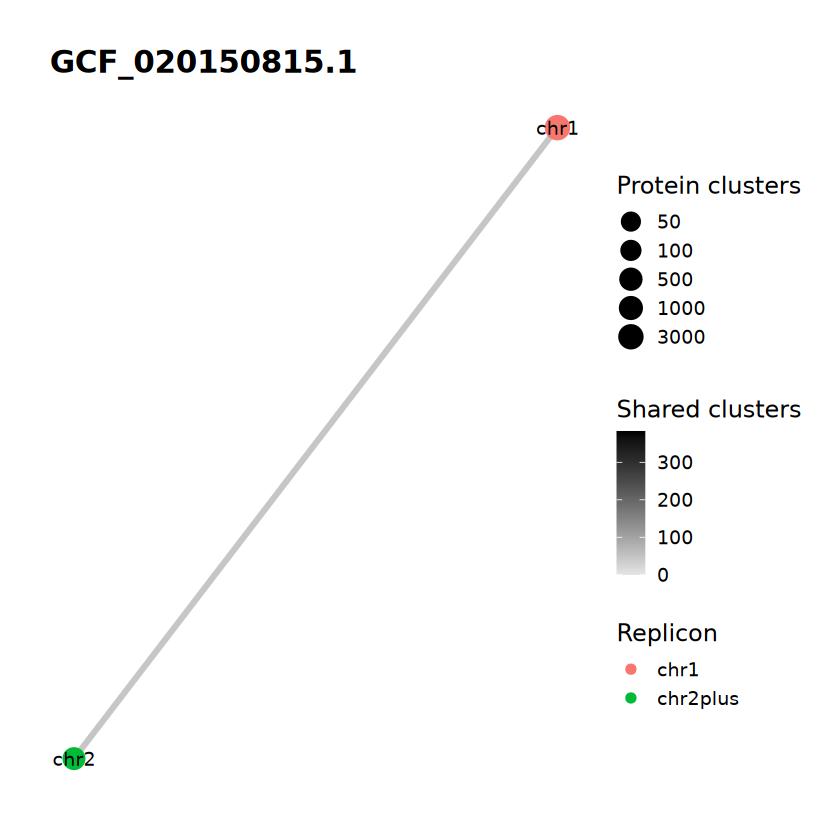

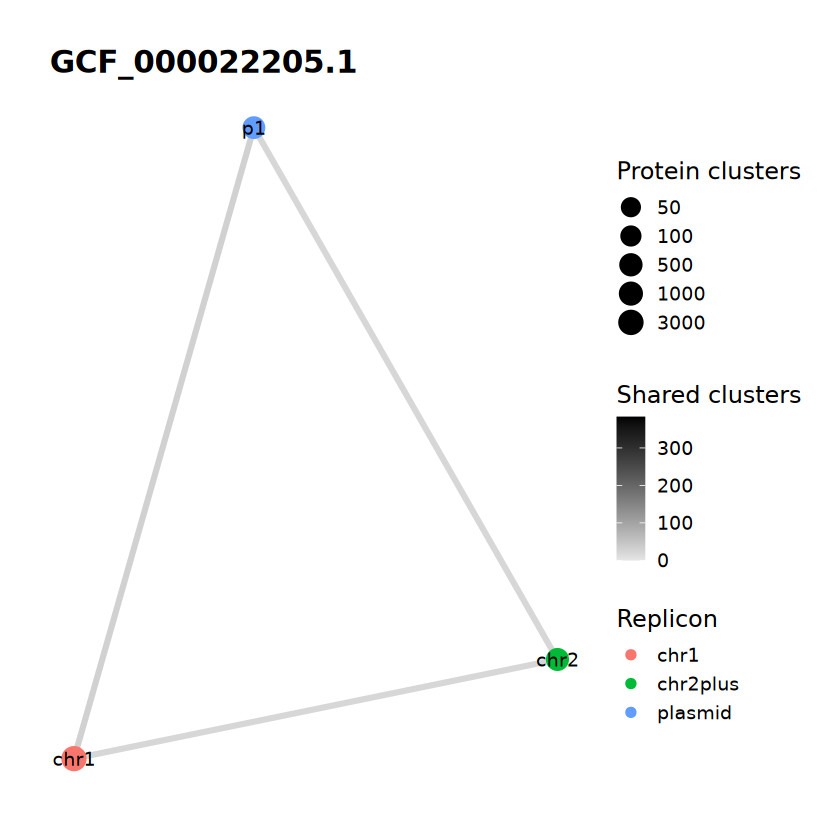

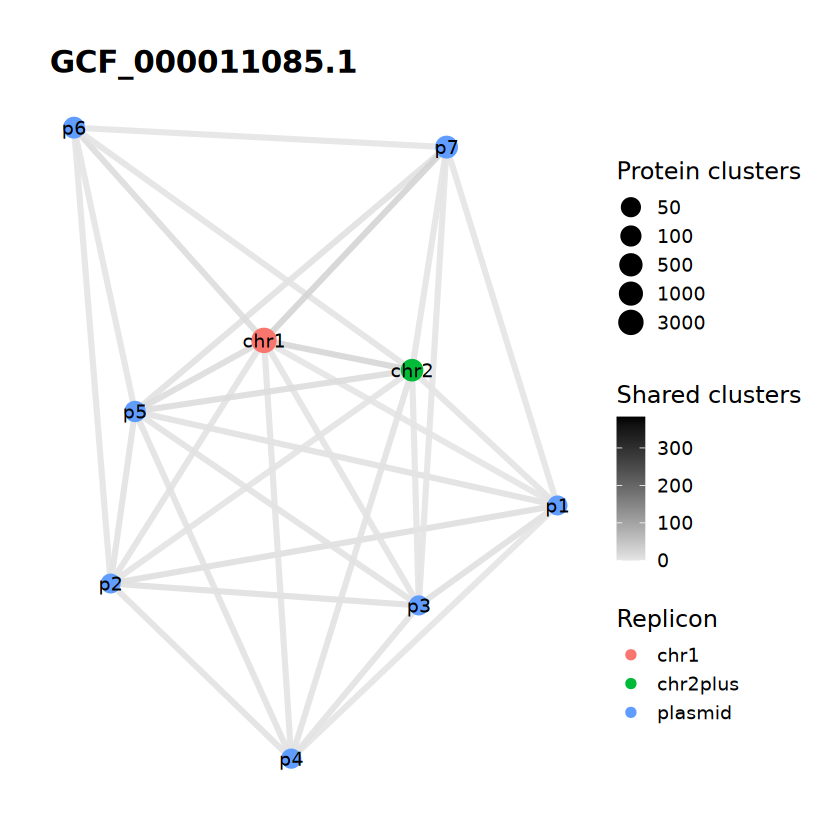

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]


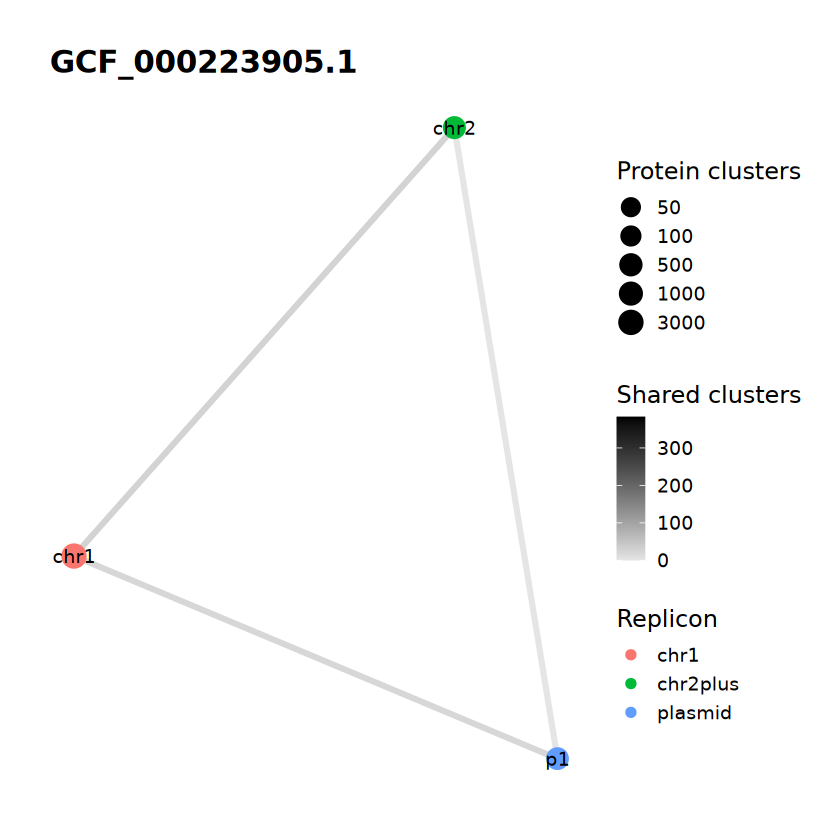

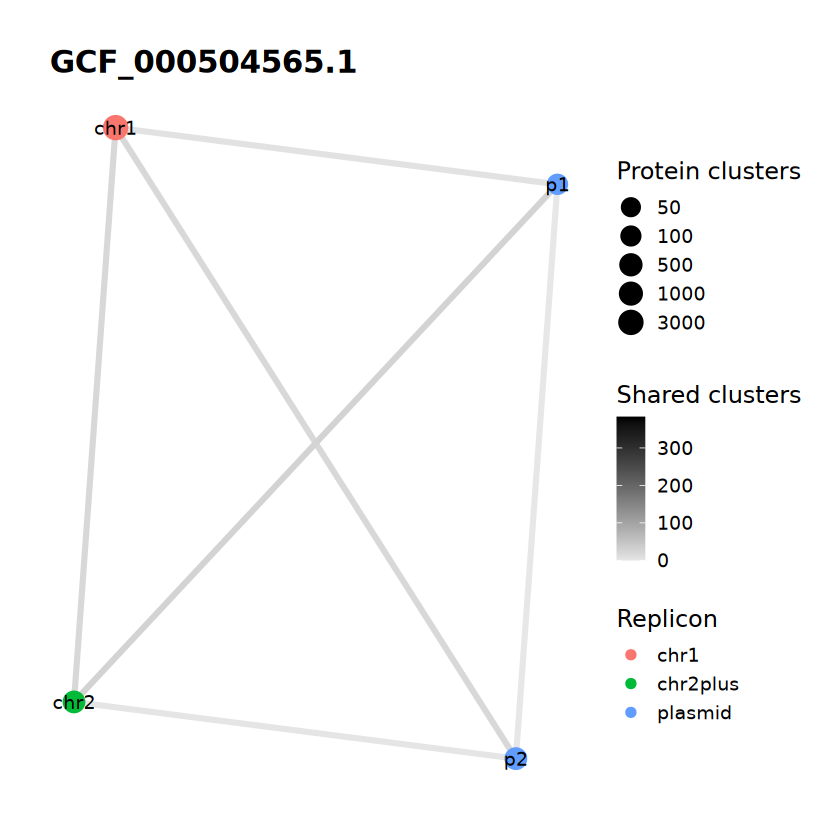

In [22]:
#Global scales
max_shared <- max(edges$shared, na.rm = TRUE)

min_size <- min(log10(nodes$size), na.rm = TRUE)
max_size <- max(log10(nodes$size), na.rm = TRUE)

#Plotting function
plot_replicon_network <- function(gen){
  edges_graph <- edges %>%
    filter(genome == gen) %>%
    select(from, to, shared, jaccard, overlap)
  nodes_graph <- nodes %>%
    filter(genome == gen) %>%
    select(name, replicon, size, label)
  g <- graph_from_data_frame(
    d = edges_graph,
    vertices = nodes_graph,
    directed = FALSE)
  ggraph(g, layout = "fr") +
    geom_edge_link(
      aes(colour = shared),
      width = 1.3,
      alpha = 0.9) +
    scale_edge_colour_gradient(
      low = "grey90",
      high = "black",
      limits = c(0, max_shared),
      name = "Shared clusters") +
    geom_node_point(
      aes(size = log10(size),
        colour = replicon)) +
    geom_node_text(
      aes(label = label),
      size = 4,
      family = "sans") +
    scale_size_continuous(
      limits = c(min_size, max_size),
      breaks = log10(c(50,100,500,1000,3000)),
      labels = c(50,100,500,1000,3000),
      name = "Protein clusters") +
    scale_colour_manual(values = c(chr1 = "#F8766D",
        chr2plus = "#00BA38",
        plasmid = "#619CFF"),
      name = "Replicon") +
    theme_graph(base_size = 14, base_family = "sans") +
    labs(title = gen)}

#Build all plots
plots <- lapply(genomes, plot_replicon_network)
combined <- wrap_plots(
  plots,
  ncol = 3,
  guides = "collect") &
theme(legend.position = "right")

plots

agg_record_130e3821f20e 
                      2

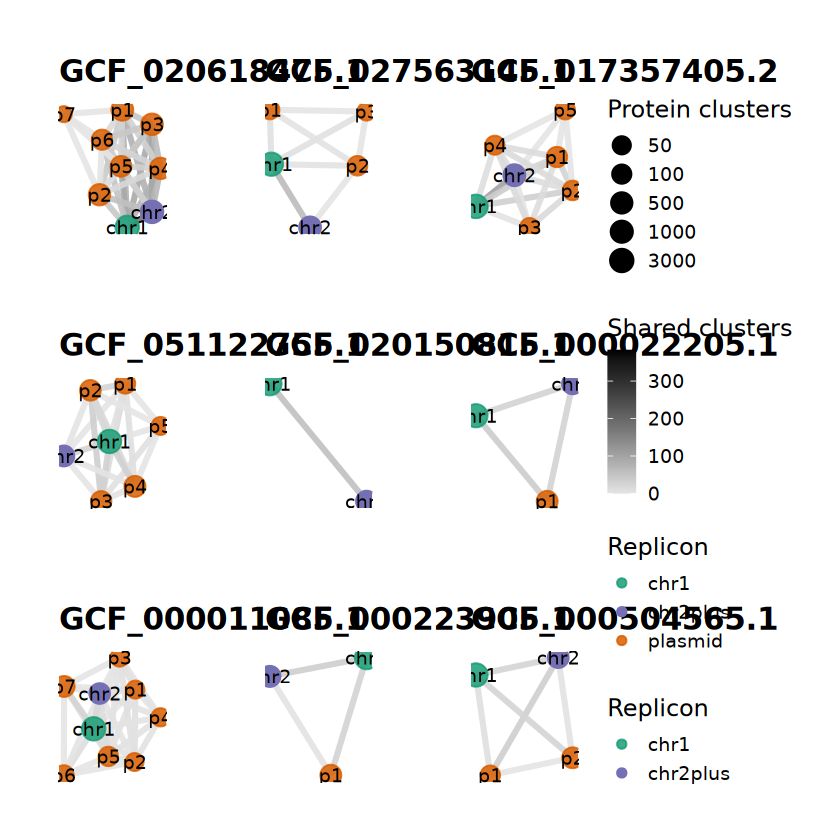

In [23]:
#Saving graphs in the same figure with the same scale
#Loading library
library(patchwork)

#Global scales
max_shared <- max(edges$shared, na.rm = TRUE)
min_size <- min(log10(nodes$size), na.rm = TRUE)
max_size <- max(log10(nodes$size), na.rm = TRUE)

#Plotting function
plot_replicon_network <- function(gen){
  edges_graph <- edges %>%
    filter(genome == gen) %>%
    select(from, to, shared, jaccard, overlap)
  nodes_graph <- nodes %>%
    filter(genome == gen) %>%
    select(name, replicon, size, label)

  g <- graph_from_data_frame(d = edges_graph,
    vertices = nodes_graph,
    directed = FALSE)

  ggraph(g, layout = "fr") +
    geom_edge_link(aes(colour = shared),
      width = 1.3,
      alpha = 0.9) +
    scale_edge_colour_gradient(
      low = "grey90",
      high = "black",
      limits = c(0, max_shared),
      name = "Shared clusters") +
    geom_node_point(aes(size = log10(size),
        colour = replicon)) +
    geom_node_text(
      aes(label = label),
      size = 4,
      family = "sans") +
    scale_size_continuous(
      limits = c(min_size, max_size),
      breaks = log10(c(50,100,500,1000,3000)),
      labels = c(50,100,500,1000,3000),
      name = "Protein clusters") +
    scale_colour_manual(
      values = c(chr1 = "#1b9e77d9",
        chr2plus = "#7570b3ff",
        plasmid = "#d95f02d9"),
      name = "Replicon") +
    theme_graph(base_size = 14,
      base_family = "sans") +
    labs(title = gen)}

#Build all plots
plots <- lapply(genomes, plot_replicon_network)

combined <- wrap_plots(plots,
  ncol = 3,
  guides = "collect") &
theme(legend.position = "right")

combined

#Save SVG
pdf("./paper/all_networks_scaled.pdf",width = 18,height = 18)
print(combined)
dev.off()

In [24]:
#Generating tables of shared clusters
#Generate all pairwise combinations
make_pairs <- function(x){
  x <- sort(unique(x))
  if(length(x) < 2)
    return(NA_character_)
  combn(x,2,
    FUN = function(z) paste(z, collapse = " ↔ "))}

#Classify clusters according to replicon types
classify_cluster <- function(labels){
  has_chr1 <- "chr1" %in% labels
  has_chr2 <- "chr2" %in% labels
  has_plasmid <- any(grepl("^p", labels))
  case_when(has_chr1 & has_chr2 & has_plasmid ~
      "Chromosome + Secondary chromosome + Plasmid",
    has_chr1 & has_chr2 ~
      "Chromosome + Secondary chromosome",
    has_chr1 & has_plasmid ~
      "Chromosome + Plasmid",
    has_chr2 & has_plasmid ~
      "Secondary chromosome + Plasmid",
    has_plasmid &
      !has_chr1 &
      !has_chr2 ~
      "Only plasmids",
    has_chr1 &
      !has_chr2 &
      !has_plasmid ~
      "Only chromosome",
    has_chr2 &
      !has_chr1 &
      !has_plasmid ~
      "Only secondary chromosome",
    TRUE ~
      "Other")}

#Build one annotation table per genome
shared_tables <- setNames(
  lapply(genomes, function(gen){
    genome_nodes <- nodes %>%
      filter(genome == gen) %>%
      select(name, label)
    master %>%
      filter(genome == gen) %>%
      distinct(cluster, contig) %>%
      left_join(genome_nodes,
        by = c("contig" = "name")) %>%
      group_by(cluster) %>%
      summarise(n_replicons = n(),
        shared_between =
          paste(sort(label), collapse = "; "),
        pairwise_edges =
          paste(make_pairs(label), collapse = "; "),
        edge_support =
          choose(n(), 2),
        cluster_class =
          classify_cluster(label),.groups = "drop") %>%
      ## Change >=2 to >=3 if desired
      filter(n_replicons >= 2) %>%
      left_join(annot,
        by = c("cluster" = "cluster")) %>%
      arrange(desc(n_replicons),
        desc(edge_support),
        cluster_class,
        cluster) %>%
      select(cluster,
    COG_category,
    Description,
    cluster_class,
    n_replicons,
    edge_support,
    shared_between,
    pairwise_edges)}),
  genomes)

#Example
shared_tables[["GCF_020618475.1"]]

#export all tables
dir.create("./paper/Shared_cluster_tables", showWarnings = FALSE)

iwalk(shared_tables,
  ~write_csv(.x,
    file.path( "./paper/Shared_cluster_tables",
      paste0(.y, "_shared_clusters.csv"))))

cluster,COG_category,Description,cluster_class,n_replicons,edge_support,shared_between,pairwise_edges
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>
MEOINMPN_03639,S,SWIM zinc finger,Chromosome + Secondary chromosome + Plasmid,7,21,chr1; chr2; p1; p3; p4; p5; p6,chr1 ↔ chr2; chr1 ↔ p1; chr1 ↔ p3; chr1 ↔ p4; chr1 ↔ p5; chr1 ↔ p6; chr2 ↔ p1; chr2 ↔ p3; chr2 ↔ p4; chr2 ↔ p5; chr2 ↔ p6; p1 ↔ p3; p1 ↔ p4; p1 ↔ p5; p1 ↔ p6; p3 ↔ p4; p3 ↔ p5; p3 ↔ p6; p4 ↔ p5; p4 ↔ p6; p5 ↔ p6
MEOINMPN_07512,,,Secondary chromosome + Plasmid,7,21,chr2; p1; p2; p3; p4; p5; p6,chr2 ↔ p1; chr2 ↔ p2; chr2 ↔ p3; chr2 ↔ p4; chr2 ↔ p5; chr2 ↔ p6; p1 ↔ p2; p1 ↔ p3; p1 ↔ p4; p1 ↔ p5; p1 ↔ p6; p2 ↔ p3; p2 ↔ p4; p2 ↔ p5; p2 ↔ p6; p3 ↔ p4; p3 ↔ p5; p3 ↔ p6; p4 ↔ p5; p4 ↔ p6; p5 ↔ p6
NOPCAMHJ_05001,,,Chromosome + Plasmid,6,15,chr1; p1; p2; p3; p4; p6,chr1 ↔ p1; chr1 ↔ p2; chr1 ↔ p3; chr1 ↔ p4; chr1 ↔ p6; p1 ↔ p2; p1 ↔ p3; p1 ↔ p4; p1 ↔ p6; p2 ↔ p3; p2 ↔ p4; p2 ↔ p6; p3 ↔ p4; p3 ↔ p6; p4 ↔ p6
BPDCMHGL_00501,-,-,Chromosome + Secondary chromosome + Plasmid,6,15,chr1; chr2; p3; p4; p5; p6,chr1 ↔ chr2; chr1 ↔ p3; chr1 ↔ p4; chr1 ↔ p5; chr1 ↔ p6; chr2 ↔ p3; chr2 ↔ p4; chr2 ↔ p5; chr2 ↔ p6; p3 ↔ p4; p3 ↔ p5; p3 ↔ p6; p4 ↔ p5; p4 ↔ p6; p5 ↔ p6
MEOINMPN_07513,,,Secondary chromosome + Plasmid,6,15,chr2; p1; p3; p4; p5; p6,chr2 ↔ p1; chr2 ↔ p3; chr2 ↔ p4; chr2 ↔ p5; chr2 ↔ p6; p1 ↔ p3; p1 ↔ p4; p1 ↔ p5; p1 ↔ p6; p3 ↔ p4; p3 ↔ p5; p3 ↔ p6; p4 ↔ p5; p4 ↔ p6; p5 ↔ p6
BCKBDMCO_03489,L,COG0675 Transposase and inactivated derivatives,Chromosome + Plasmid,5,10,chr1; p1; p2; p3; p4,chr1 ↔ p1; chr1 ↔ p2; chr1 ↔ p3; chr1 ↔ p4; p1 ↔ p2; p1 ↔ p3; p1 ↔ p4; p2 ↔ p3; p2 ↔ p4; p3 ↔ p4
MEOINMPN_01148,,,Chromosome + Plasmid,5,10,chr1; p1; p3; p4; p6,chr1 ↔ p1; chr1 ↔ p3; chr1 ↔ p4; chr1 ↔ p6; p1 ↔ p3; p1 ↔ p4; p1 ↔ p6; p3 ↔ p4; p3 ↔ p6; p4 ↔ p6
MEOINMPN_05577,,,Chromosome + Plasmid,5,10,chr1; p1; p3; p4; p6,chr1 ↔ p1; chr1 ↔ p3; chr1 ↔ p4; chr1 ↔ p6; p1 ↔ p3; p1 ↔ p4; p1 ↔ p6; p3 ↔ p4; p3 ↔ p6; p4 ↔ p6
OOCIPGNO_03850,K,transcriptional regulators containing the CopG Arc MetJ DNA-binding domain and a metal-binding domain,Chromosome + Plasmid,5,10,chr1; p1; p3; p5; p6,chr1 ↔ p1; chr1 ↔ p3; chr1 ↔ p5; chr1 ↔ p6; p1 ↔ p3; p1 ↔ p5; p1 ↔ p6; p3 ↔ p5; p3 ↔ p6; p5 ↔ p6


In [32]:
#Determien the fraction of shared clusters per replicon
shared_proportions <- lapply(genomes, function(gen) {
  m <- master %>%
    filter(genome == gen) %>%
    distinct(cluster, contig, replicon)

  total <- m %>%
    distinct(cluster, replicon) %>%
    count(replicon, name = "Total_clusters")

  shared <- m %>%
    distinct(cluster, replicon) %>%
    group_by(cluster) %>%
    filter(n_distinct(replicon) >= 2) %>%
    ungroup() %>%
    count(replicon, name = "Shared_clusters")

  total %>%
    left_join(shared, by = "replicon") %>%
    mutate(
      Shared_clusters = replace_na(Shared_clusters, 0),
      Proportion_shared = Shared_clusters / Total_clusters,
      Percent_shared = 100 * Proportion_shared,
      genome = gen
    ) %>%
    select(genome, replicon, Total_clusters,
           Shared_clusters, Proportion_shared, Percent_shared)
})

shared_proportions <- bind_rows(shared_proportions)

shared_proportions

genome,replicon,Total_clusters,Shared_clusters,Proportion_shared,Percent_shared
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
GCF_020618475.1,chr1,3079,398,0.12926275,12.926275
GCF_020618475.1,chr2plus,1378,350,0.25399129,25.399129
GCF_020618475.1,plasmid,2579,482,0.18689415,18.689415
GCF_027563145.1,chr1,2721,79,0.02903344,2.903344
GCF_027563145.1,chr2plus,734,64,0.08719346,8.719346
GCF_027563145.1,plasmid,268,18,0.06716418,6.716418
GCF_017357405.2,chr1,3664,153,0.04175764,4.175764
GCF_017357405.2,chr2plus,802,124,0.15461347,15.461347
GCF_017357405.2,plasmid,568,91,0.16021127,16.021127


In [25]:
#Generate and save one shared-cluster count table per genome
shared_counts <- lapply(shared_tables, function(tab) {
  tab %>%
    mutate(COG_category = ifelse(
        is.na(COG_category) | COG_category == "",
        "Unclassified",
        COG_category)) %>%
    count(cluster_class,
      COG_category,
      name = "N_clusters") %>%
    pivot_wider(names_from = COG_category,
      values_from = N_clusters,
      values_fill = 0) %>%
    arrange(cluster_class)})

#Keep genome names as table names
names(shared_counts) <- names(shared_tables)

#Create output directory
dir.create("./paper/Shared_cluster_counts",
  showWarnings = FALSE)

# Save one CSV per genome
iwalk(shared_counts,
  ~write_csv(.x,
    file.path("./paper/Shared_cluster_counts",
      paste0(.y, "_shared_cluster_counts.csv"))))

In [26]:
#Annotating with FANTASIA
#FANTASIA GO annotations
fantasia <- read_tsv("fantasia/fantasia_GO_annotations.tsv")

# Mapping between Prokka IDs and FANTASIA IDs
mapping <- read_tsv(
  "arch_cluster_master_gc_NEW.tsv",
  col_names = c("cluster",
    "protein",
    "genome",
    "contig",
    "replicon",
    "fantasia_protein",
    "gc"))

dir.create("./paper/NoCOG_FANTASIA_tables", showWarnings = FALSE)

imap(shared_tables, function(tbl, genome_id){

  # Clusters lacking a COG assignment
  no_cog <- tbl %>%
    filter(is.na(COG_category) |
      COG_category == "" |
      COG_category == "-") %>%
    select(cluster,
      cluster_class,
      COG_category,
      Description) %>%
    distinct()

  # Recover proteins from those clusters
  proteins <- master %>%
    filter(genome == genome_id,
      cluster %in% no_cog$cluster) %>%
    left_join(no_cog, by = "cluster") %>%
    left_join(mapping %>%
        select(protein, genome, fantasia_protein),
      by = c("protein", "genome"))

  # Add FANTASIA annotations
  result <- proteins %>%
    left_join(fantasia,
      by = c("fantasia_protein" = "protein",
             "genome")) %>%
    arrange(cluster, protein)

  write_csv(result,
    file.path("./paper/NoCOG_FANTASIA_tables",
      paste0(genome_id, "_NoCOG_FANTASIA.csv")))
})

Rows: 4364182 Columns: 5
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (5): protein, GO, genome, ontology, name

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 887301 Columns: 7
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (6): cluster, protein, genome, contig, replicon, fantasia_protein
dbl (1): gc

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cluster,protein,genome,contig,replicon,phylum,family,cluster_class,COG_category,Description,fantasia_protein,GO,ontology,name
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
ABDKKCFH_01373,MEOINMPN_03069,GCF_020618475.1,NZ_CP085335.1,chr1,Halobacteriota,Haladaptataceae,Chromosome + Secondary chromosome + Plasmid,-,-,NZ_CP085335.1_3030,GO:0005737,CC,cytoplasm
ABDKKCFH_01373,MEOINMPN_03069,GCF_020618475.1,NZ_CP085335.1,chr1,Halobacteriota,Haladaptataceae,Chromosome + Secondary chromosome + Plasmid,-,-,NZ_CP085335.1_3030,GO:0003677,MF,DNA binding
ABDKKCFH_01373,MEOINMPN_03069,GCF_020618475.1,NZ_CP085335.1,chr1,Halobacteriota,Haladaptataceae,Chromosome + Secondary chromosome + Plasmid,-,-,NZ_CP085335.1_3030,GO:0006352,BP,"DNA-templated transcription, initiation"
ABDKKCFH_01373,MEOINMPN_03069,GCF_020618475.1,NZ_CP085335.1,chr1,Halobacteriota,Haladaptataceae,Chromosome + Secondary chromosome + Plasmid,-,-,NZ_CP085335.1_3030,GO:0005694,CC,chromosome
ABDKKCFH_01373,MEOINMPN_03069,GCF_020618475.1,NZ_CP085335.1,chr1,Halobacteriota,Haladaptataceae,Chromosome + Secondary chromosome + Plasmid,-,-,NZ_CP085335.1_3030,GO:0046982,MF,protein heterodimerization activity
ABDKKCFH_01373,MEOINMPN_03530,GCF_020618475.1,NZ_CP085336.1,chr2plus,Halobacteriota,Haladaptataceae,Chromosome + Secondary chromosome + Plasmid,-,-,NZ_CP085336.1_185,GO:0005737,CC,cytoplasm
ABDKKCFH_01373,MEOINMPN_03530,GCF_020618475.1,NZ_CP085336.1,chr2plus,Halobacteriota,Haladaptataceae,Chromosome + Secondary chromosome + Plasmid,-,-,NZ_CP085336.1_185,GO:0003677,MF,DNA binding
ABDKKCFH_01373,MEOINMPN_03530,GCF_020618475.1,NZ_CP085336.1,chr2plus,Halobacteriota,Haladaptataceae,Chromosome + Secondary chromosome + Plasmid,-,-,NZ_CP085336.1_185,GO:0006352,BP,"DNA-templated transcription, initiation"
ABDKKCFH_01373,MEOINMPN_03530,GCF_020618475.1,NZ_CP085336.1,chr2plus,Halobacteriota,Haladaptataceae,Chromosome + Secondary chromosome + Plasmid,-,-,NZ_CP085336.1_185,GO:0005694,CC,chromosome


In [27]:
#Calculating GC content

In [28]:
#Gene-level table
genes <- read.delim("arch_cluster_master_gc_NEW.tsv",
                    header = FALSE, stringsAsFactors = FALSE)

colnames(genes) <- c("cluster",
  "protein",
  "genome",
  "contig",
  "replicon_type",
  "prodigal_id",
  "gene_gc" )

#Replicon-level table
replicons <- read.delim("replicon_features_full.tsv",
                        stringsAsFactors = FALSE) %>%
  select(genome, contig, replicon, gc_content)

#Merge
gc_master <- genes %>%
  left_join(replicons,
            by = c("genome", "contig")) %>%
  mutate(gene_gc = gene_gc * 100,
    delta_gc = gene_gc - gc_content) %>%
    filter(replicon_type != "unknown")

#Quick QC
summary(gc_master$delta_gc)
sum(is.na(gc_master$delta_gc))
head(gc_master)

write.table(gc_master,"./paper/gc_master.tsv", sep = "\t", quote = FALSE, row.names = FALSE)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
-38.960  -1.700   1.150   0.441   3.520  34.850     542 

[1] 542

,cluster,protein,genome,contig,replicon_type,prodigal_id,gene_gc,replicon,gc_content,delta_gc
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,BKFBJDIK_00146,BKFBJDIK_00146,GCF_000969945.1,NZ_CP009524.1,chr1,NZ_CP009524.1_145,44.6,chr1,39.91,4.69
2,BKFBJDIK_00146,OAPEMJJH_03971,GCF_000969985.1,NZ_CP009526.1,chr1,NZ_CP009526.1_3920,44.1,chr1,39.28,4.82
3,BKFBJDIK_00146,NFPFFJMG_03584,GCF_000970065.1,NZ_CP009530.1,chr1,NZ_CP009530.1_3538,44.6,chr1,39.25,5.35
4,BKFBJDIK_00146,FPPDMBCC_00145,GCF_000969905.1,NZ_CP009520.1,chr1,NZ_CP009520.1_143,44.6,chr1,39.78,4.82
5,BKFBJDIK_00146,FMDHGICI_03667,GCF_000970025.1,NZ_CP009528.1,chr1,NZ_CP009528.1_3627,44.6,chr1,39.23,5.37
6,BKFBJDIK_00146,CEIJLHDF_00922,GCF_000328665.1,NC_019977.1,chr1,NC_019977.1_903,45.2,chr1,42.62,2.58


In [29]:
#Load GC master table
gc_master <- read.delim("./paper/gc_master.tsv", stringsAsFactors = FALSE)

#Load shared cluster tables
files <- list.files("./paper/Shared_cluster_tables",
  pattern = "_shared_clusters.csv$",
  full.names = TRUE)

shared_clusters <- map_dfr(files, function(f){
  read_csv(f, show_col_types = FALSE) %>%
    mutate(genome = basename(f) %>%
        str_remove("_shared_clusters\\.csv$"))})

#Keep only shared clusters
shared_gc <- gc_master %>%
  semi_join(shared_clusters,
    by = c("genome","cluster")) %>%
  left_join(shared_clusters %>%
      distinct(genome, cluster, cluster_class),
    by = c("genome","cluster"))

Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_text()`).”
Saving 6.67 x 6.67 in image
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_text()`).”


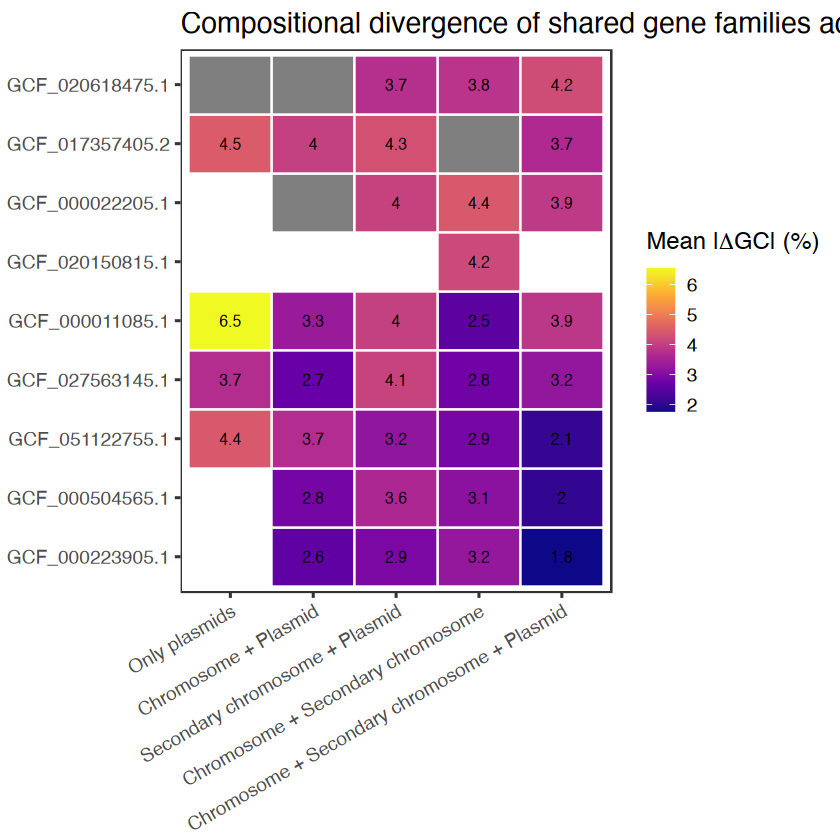

In [30]:
#Genome x cluster class summary
heatmap_df <- shared_gc %>%
  mutate(abs_delta_gc = abs(delta_gc)) %>%
  group_by(genome, cluster_class) %>%
  summarise(mean_abs_delta = mean(abs_delta_gc),
    median_abs_delta = median(abs_delta_gc),
    n_genes = n(),
    .groups = "drop")

#Order genomes by overall divergence
genome_order <- heatmap_df %>%
  group_by(genome) %>%
  summarise(overall = mean(mean_abs_delta)) %>%
  arrange(overall) %>%
  pull(genome)

heatmap_df$genome <- factor(
  heatmap_df$genome,
  levels = genome_order)

heatmap_df$cluster_class <- factor(
  heatmap_df$cluster_class,
  levels = c("Only plasmids",
    "Chromosome + Plasmid",
    "Secondary chromosome + Plasmid",
    "Chromosome + Secondary chromosome",
    "Chromosome + Secondary chromosome + Plasmid"))

#Heatmap
p <- ggplot(heatmap_df,
  aes(cluster_class,
    genome,
    fill = mean_abs_delta)) +
  geom_tile(color = "white", linewidth = 0.5) +
  geom_text(aes(label = round(mean_abs_delta, 1)),
    size = 3.2,
    color = "black") +
  scale_fill_viridis_c(option = "C",
    name = expression("Mean "* "|" * Delta * "GC| (%)")) +
  labs(x = NULL,
    y = NULL,
    title = "Compositional divergence of shared gene families across archaeal genomes") +
  theme_bw(base_size = 14) +
  theme(panel.grid = element_blank(),
    axis.text.x = element_text(angle = 30, hjust = 1),
    plot.title = element_text(face = "bold"))

print(p)
ggsave("./paper/gc_comparison.svg")